In [1]:
#Sibsusiso Mathebula
# Cosmology Tutorial 3

In [2]:
import numpy as np
import scipy as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
h=0.7
H0 = 100*h
Omega_m = 0.3
Omega_r = 1e-4
Omega_k=0.0
Omega_l = 1-Omega_m-Omega_r

def Hubble(z):
    return H0 * np.sqrt(
        Omega_r * (1 + z)**4 +
        Omega_m * (1 + z)**3 +
        Omega_k * (1 + z)**2 +
        Omega_l
    )

In [4]:
c = 299792.458      # km/s
        # km/s/Mpc



def f(z):
    return c/Hubble(z)

def comoving_trapezoidal(z, N=1000):
    z_vals = np.linspace(0, z, N+1)
    h = z / N

    integral = (h/2) * (
        f(z_vals[0]) +
        2*np.sum(f(z_vals[1:N])) +
        f(z_vals[N])
    )

    return  integral

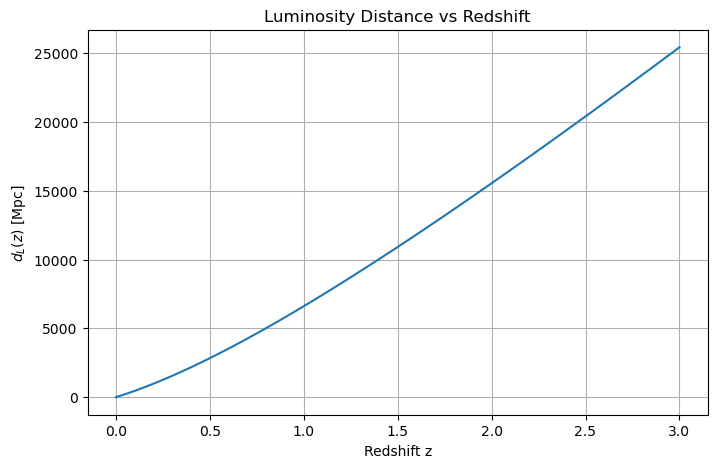

In [5]:
# Question 3 (a)

z_values = np.linspace(0, 3, 500)

chi_values = np.array([
    comoving_trapezoidal(z, N=2000)
    for z in z_values
])

dL = (1 + z_values) * chi_values

plt.figure(figsize=(8, 5))
plt.plot(z_values, dL)
plt.xlabel("Redshift z")
plt.ylabel(r"$d_L(z)$ [Mpc]")
plt.title("Luminosity Distance vs Redshift")
plt.grid(True)
plt.show()

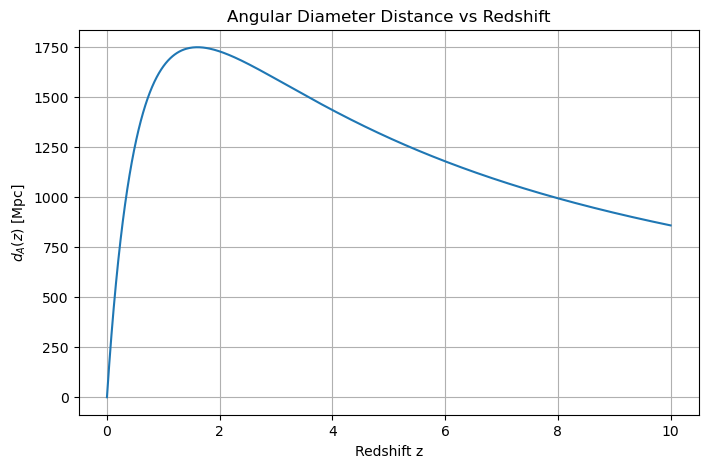

In [6]:
# Question 3 b

z_values = np.linspace(0, 10, 500)

chi_values = np.array([
    comoving_trapezoidal(z, N=2000)
    for z in z_values
])

dA = chi_values / (1 + z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, dA)
plt.xlabel("Redshift z")
plt.ylabel(r"$d_A(z)$ [Mpc]")
plt.title("Angular Diameter Distance vs Redshift")
plt.grid(True)
plt.show()

In [7]:
# Question 3c (i): Maximum angular diameter distance

from scipy.optimize import minimize_scalar

def dA_function(z):
    chi_z = comoving_trapezoidal(z, N=5000)
    return chi_z / (1 + z)

result = minimize_scalar(
    lambda z: -dA_function(z),
    bounds=(0, 10),
    method='bounded'
)

z_max = result.x
dA_max = dA_function(z_max)

print("Redshift at maximum d_A =", z_max)
print("Maximum d_A =", dA_max, "Mpc")

Redshift at maximum d_A = 1.6050019915474918
Maximum d_A = 1747.2889678870029 Mpc


In [8]:

# Question 3(c)(ii): d_A at z = 1090


z_cmb = 1090

chi_cmb = comoving_trapezoidal(z_cmb, N=10000)

dA_cmb = chi_cmb / (1 + z_cmb)

print("Comoving distance at z = 1090 =", chi_cmb, "Mpc")
print("d_A at z = 1090 =", dA_cmb, "Mpc")

Comoving distance at z = 1090 = 13607.473534032764 Mpc
d_A at z = 1090 = 12.472478033027281 Mpc


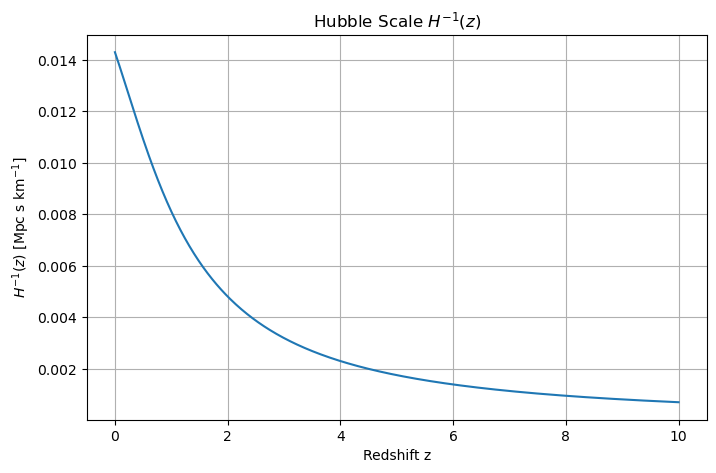

H^(-1) at z = 1090 = 6.19797890922407e-07 Mpc s km^(-1)


In [9]:

# Question 3(d): Hubble scale H^(-1)(z)

z_values = np.linspace(0, 10, 500)

H_inv = 1 / Hubble(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, H_inv)
plt.xlabel("Redshift z")
plt.ylabel(r"$H^{-1}(z)$ [Mpc s km$^{-1}$]")
plt.title(r"Hubble Scale $H^{-1}(z)$")
plt.grid(True)
plt.show()

# Value at z = 1090
H_inv_1090 = 1 / Hubble(1090)

print("H^(-1) at z = 1090 =", H_inv_1090,
      "Mpc s km^(-1)")

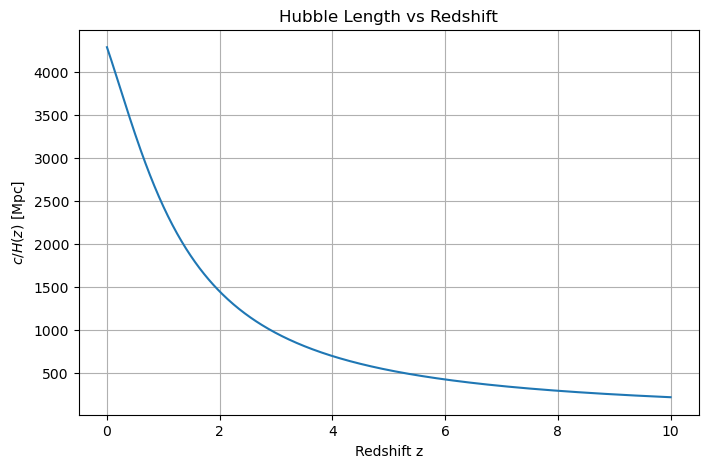

Hubble length c/H at z = 1090 = 0.18581073318284425 Mpc


In [10]:
Hubble_length = c / Hubble(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, Hubble_length)
plt.xlabel("Redshift z")
plt.ylabel(r"$c/H(z)$ [Mpc]")
plt.title("Hubble Length vs Redshift")
plt.grid(True)
plt.show()

print("Hubble length c/H at z = 1090 =",
      c / Hubble(1090), "Mpc")

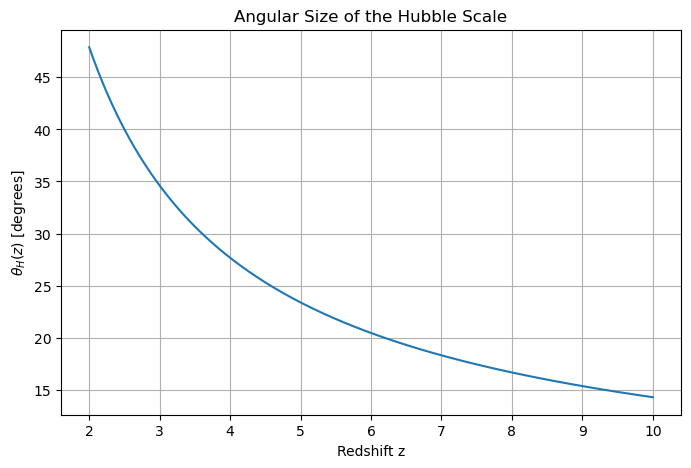

theta_H at z = 1090 = 0.8535730246561443 degrees


In [11]:

# Question 3(e): Angular size of the Hubble scale


z_values = np.linspace(2, 10, 500)

chi_values = np.array([
    comoving_trapezoidal(z, N=2000)
    for z in z_values
])

dA_values = chi_values / (1 + z_values)

Hubble_length = c / Hubble(z_values)

theta_H = Hubble_length / dA_values

# Convert radians to degrees
theta_H_deg = np.degrees(theta_H)

plt.figure(figsize=(8, 5))
plt.plot(z_values, theta_H_deg)
plt.xlabel("Redshift z")
plt.ylabel(r"$\theta_H(z)$ [degrees]")
plt.title("Angular Size of the Hubble Scale")
plt.grid(True)
plt.show()

# Value at z = 1090
chi_1090 = comoving_trapezoidal(1090, N=10000)
dA_1090 = chi_1090 / (1 + 1090)

theta_H_1090 = (c / Hubble(1090)) / dA_1090
theta_H_1090_deg = np.degrees(theta_H_1090)

print("theta_H at z = 1090 =",
      theta_H_1090_deg, "degrees")

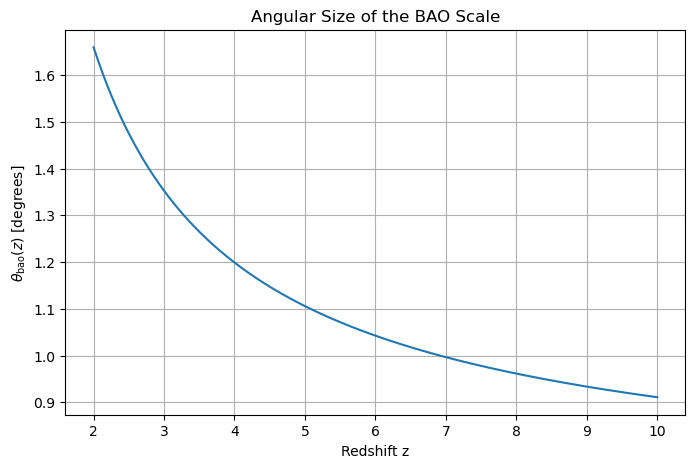

BAO scale at z = 1090 = 0.13748854262144822 Mpc
theta_bao at z = 1090 = 0.6315916694945273 degrees


In [12]:

# Question 3(f): Angular size of the BAO scale


chi_values = np.array([
    comoving_trapezoidal(z, N=2000)
    for z in z_values
])

dA_values = chi_values / (1 + z_values)

R_bao = 150 / (1 + z_values)   # Mpc

theta_bao = R_bao / dA_values

# Convert radians to degrees
theta_bao_deg = np.degrees(theta_bao)

plt.figure(figsize=(8, 5))
plt.plot(z_values, theta_bao_deg)
plt.xlabel("Redshift z")
plt.ylabel(r"$\theta_{\rm bao}(z)$ [degrees]")
plt.title("Angular Size of the BAO Scale")
plt.grid(True)
plt.show()

# Value at z = 1090
R_bao_1090 = 150 / (1 + 1090)

theta_bao_1090 = R_bao_1090 / dA_1090
theta_bao_1090_deg = np.degrees(theta_bao_1090)

print("BAO scale at z = 1090 =",
      R_bao_1090, "Mpc")

print("theta_bao at z = 1090 =",
      theta_bao_1090_deg, "degrees")